## Student Adacemic Performence Prediction

In [8]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [9]:
df = pd.read_csv("../data/student_performance_dataset.csv")

df.head()

,student_id,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
0,0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,2,16,Female,Urban,4.3,7,54,57,4.3,1,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,4,17,Female,Urban,4.1,3,100,81,2.6,0,...,5,6,Visual,Medical,4,10,7,9,77,High


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   student_id                   3000 non-null   int64  
 1   age                          3000 non-null   int64  
 2   gender                       3000 non-null   str    
 3   city_type                    3000 non-null   str    
 4   study_hours_per_day          3000 non-null   float64
 5   deep_work_sessions           3000 non-null   int64  
 6   assignment_completion_rate   3000 non-null   int64  
 7   attendance_percentage        3000 non-null   int64  
 8   social_media_hours           2940 non-null   float64
 9   doomscrolling_before_sleep   3000 non-null   int64  
 10  notification_distractions    3000 non-null   int64  
 11  ai_tool_usage_hours          3000 non-null   float64
 12  gaming_hours                 3000 non-null   float64
 13  stress_level                 

### 1. Explore data

1. This dataset has 31 attr, two of which have 60 missing values `focus_score` & `social_media_hours`. These attr seems important to me, so removing is not a options. I would most likely use `SimpleImputer` to fill these values with the means of the dataset.
2. `Student_id` is not relevant for the prediction -> set as index for data.
3. Categories
    1. "Binary": [gender],
    2. "multi-class": [performance_category, career_goal, learning_style, mental_state, city_type]

In [12]:
df = df.set_index("student_id")
df.head()

,age,gender,city_type,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,...,family_support,financial_stress,learning_style,career_goal,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score,performance_category
student_id,,,,,,,,,,,,,,,,,,,,,
0,21,Female,Semi-Urban,3.2,7,100,70,3.8,0,107,...,10,6,Audio,Engineering,9,1,10,3,32,Low
1,19,Female,Semi-Urban,3.9,2,46,70,2.6,1,93,...,2,6,Practical,Business,6,10,4,6,59,Medium
2,16,Female,Urban,4.3,7,54,57,4.3,1,82,...,1,9,Visual,Engineering,7,9,8,1,34,Low
3,19,Male,Semi-Urban,5.3,1,78,90,1.7,0,27,...,5,10,Reading,Medical,7,7,9,10,60,Medium
4,17,Female,Urban,4.1,3,100,81,2.6,0,8,...,5,6,Visual,Medical,4,10,7,9,77,High


In [14]:
# Make a muneric dataset

numeric_attr = df.select_dtypes(include="number")
numeric_attr.head()

,age,study_hours_per_day,deep_work_sessions,assignment_completion_rate,attendance_percentage,social_media_hours,doomscrolling_before_sleep,notification_distractions,ai_tool_usage_hours,gaming_hours,...,caffeine_intake,physical_activity_hours,internet_quality,family_support,financial_stress,productivity_after_midnight,revision_efficiency,burnout_risk,consistency_score,final_exam_score
student_id,,,,,,,,,,,,,,,,,,,,,
0,21,3.2,7,100,70,3.8,0,107,0.6,1.8,...,4,0.6,1,10,6,9,1,10,3,32
1,19,3.9,2,46,70,2.6,1,93,1.5,1.1,...,5,0.0,4,2,6,6,10,4,6,59
2,16,4.3,7,54,57,4.3,1,82,0.5,0.0,...,4,1.3,9,1,9,7,9,8,1,34
3,19,5.3,1,78,90,1.7,0,27,1.4,3.8,...,2,1.3,1,5,10,7,7,9,10,60
4,17,4.1,3,100,81,2.6,0,8,1.3,2.5,...,5,1.7,9,5,6,4,10,7,9,77


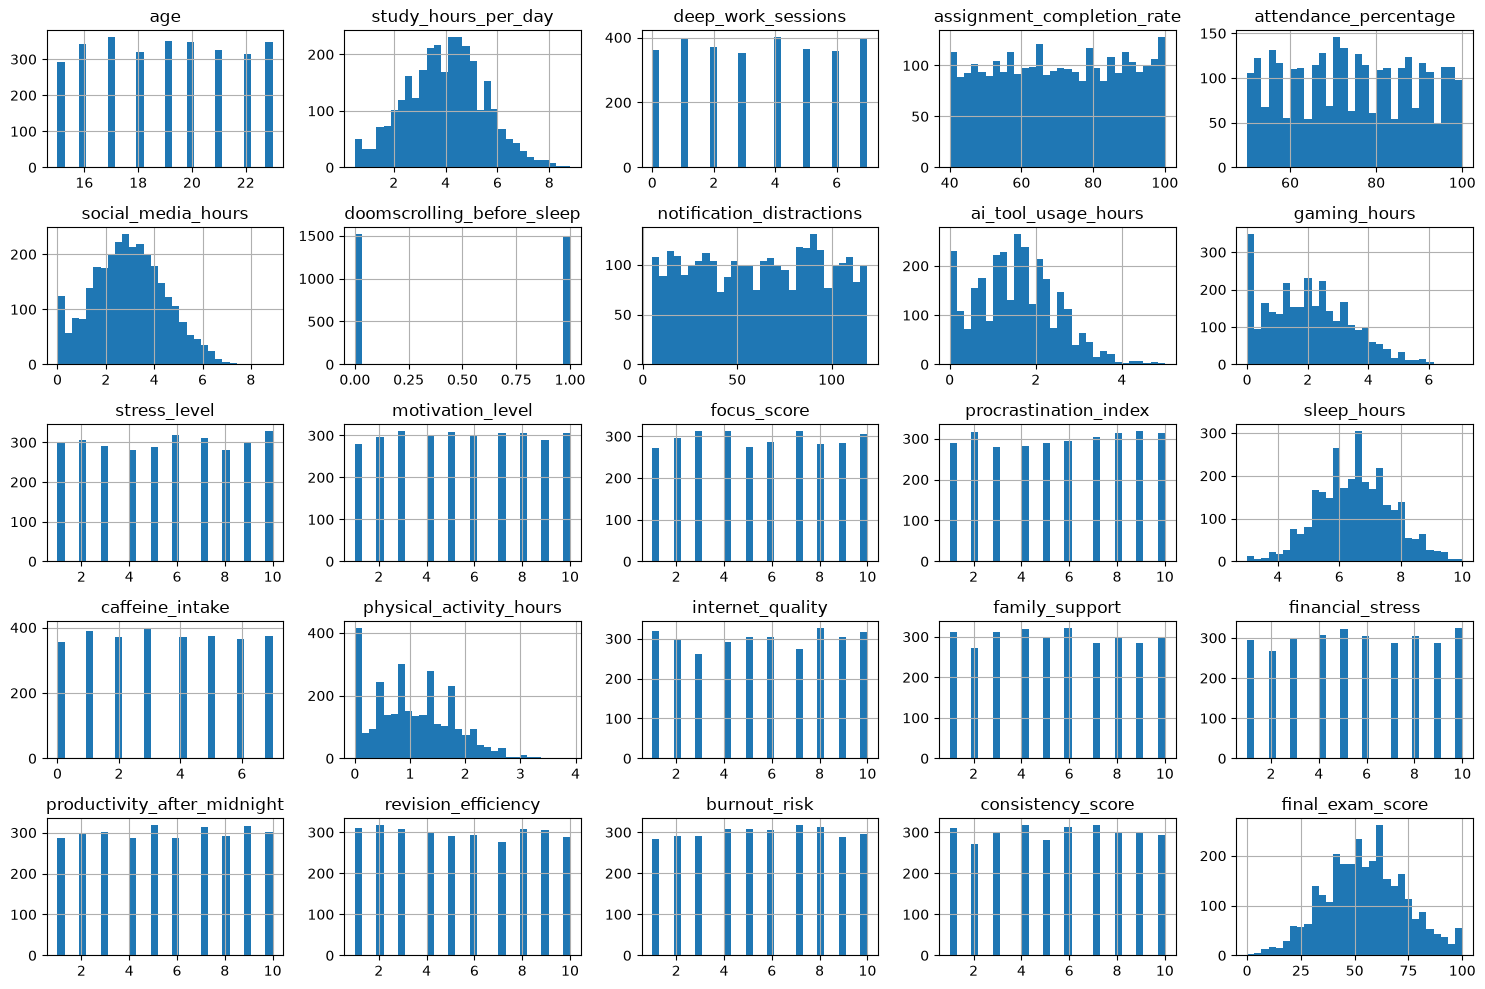

In [20]:
# Plot numeric attributes
numeric_attr.hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show();

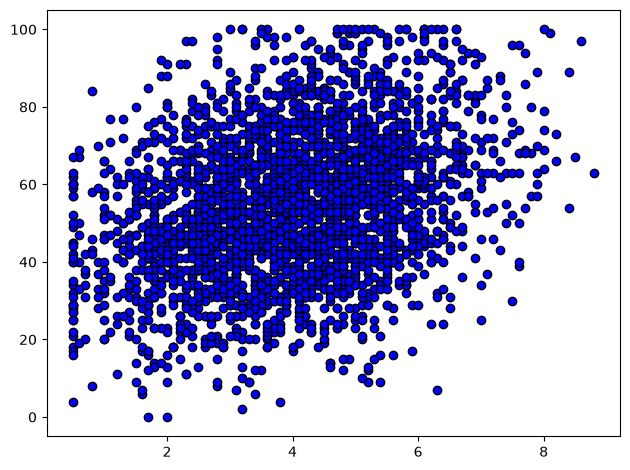

In [24]:
X_numeric, y_numeric = numeric_attr.drop(columns="final_exam_score"), numeric_attr["final_exam_score"]
plt.scatter(X_numeric["study_hours_per_day"], y_numeric, c="b", edgecolors="black")
plt.tight_layout()
plt.show();